# ML Training on Real EVTX Attack Samples

**Dataset:** EVTX-ATTACK-SAMPLES (9,886 events)
**Goal:** Train models with real accuracy/precision/recall metrics

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    precision_score, recall_score, roc_auc_score, roc_curve, 
    precision_recall_curve, average_precision_score
)
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries loaded!')

Libraries loaded!


## 1. Load Dataset

In [2]:
# Load EVTX Attack Samples dataset
df = pd.read_csv('datasets/EVTX-ATTACK-SAMPLES/evtx_data.csv', low_memory=False)

print(f'Total events: {len(df):,}')
print(f'Columns: {len(df.columns)}')
print(f'\nTactics distribution:')
print(df['EVTX_Tactic'].value_counts())

Total events: 4,633
Columns: 326

Tactics distribution:
EVTX_Tactic
Lateral Movement        1288
Privilege Escalation    1088
Execution                533
Command and Control      432
Defense Evasion          431
Persistence              411
Credential Access        283
Discovery                167
Name: count, dtype: int64


In [3]:
# Key columns for analysis
key_cols = ['EventID', 'EVTX_Tactic', 'Channel', 'Computer', 'ProcessName', 
            'CommandLine', 'Image', 'ParentImage', 'ParentCommandLine',
            'TargetUserName', 'SubjectUserName', 'LogonType', 'DestinationPort']

# Check which key columns exist
existing_cols = [c for c in key_cols if c in df.columns]
print(f'Key columns available: {existing_cols}')

# Show sample
df[existing_cols].head(10)

Key columns available: ['EventID', 'EVTX_Tactic', 'Channel', 'Computer', 'ProcessName', 'CommandLine', 'Image', 'ParentImage', 'ParentCommandLine', 'TargetUserName', 'SubjectUserName', 'LogonType', 'DestinationPort']


,EventID,EVTX_Tactic,Channel,Computer,ProcessName,CommandLine,Image,ParentImage,ParentCommandLine,TargetUserName,SubjectUserName,LogonType,DestinationPort
0,4624,Command and Control,Security,PC02.example.corp,C:\Windows\System32\services.exe,NaN,NaN,NaN,NaN,SYSTEM,PC02$,5.0,NaN
1,4624,Command and Control,Security,PC02.example.corp,NaN,NaN,NaN,NaN,NaN,SYSTEM,-,0.0,NaN
2,4624,Command and Control,Security,PC02.example.corp,C:\Windows\System32\services.exe,NaN,NaN,NaN,NaN,SYSTEM,PC02$,5.0,NaN
3,4624,Command and Control,Security,PC02.example.corp,C:\Windows\System32\services.exe,NaN,NaN,NaN,NaN,NETWORK SERVICE,PC02$,5.0,NaN
4,4624,Command and Control,Security,PC02.example.corp,C:\Windows\System32\services.exe,NaN,NaN,NaN,NaN,LOCAL SERVICE,PC02$,5.0,NaN
5,4624,Command and Control,Security,PC02.example.corp,C:\Windows\System32\services.exe,NaN,NaN,NaN,NaN,SYSTEM,PC02$,5.0,NaN
6,4624,Command and Control,Security,PC02.example.corp,C:\Windows\System32\services.exe,NaN,NaN,NaN,NaN,SYSTEM,PC02$,5.0,NaN
7,4624,Command and Control,Security,PC02.example.corp,C:\Windows\System32\services.exe,NaN,NaN,NaN,NaN,SYSTEM,PC02$,5.0,NaN
8,4624,Command and Control,Security,PC02.example.corp,C:\Windows\System32\services.exe,NaN,NaN,NaN,NaN,SYSTEM,PC02$,5.0,NaN
9,4624,Command and Control,Security,PC02.example.corp,C:\Windows\System32\services.exe,NaN,NaN,NaN,NaN,sshd_server,PC02$,5.0,NaN


## 2. Data Preprocessing & Feature Engineering

In [4]:
# Create binary label: malicious (attack tactic) vs benign
# All events in this dataset are from attack samples, so we'll create synthetic benign baseline
# OR use tactic-based severity levels

# High severity tactics (definitely malicious)
high_severity_tactics = [
    'Credential Access', 'Lateral Movement', 'Privilege Escalation',
    'Defense Evasion', 'Command and Control', 'Execution'
]

# Medium severity
medium_severity_tactics = ['Discovery', 'Persistence', 'Other']

# Create severity score
def get_severity(tactic):
    if pd.isna(tactic):
        return 0
    if any(t in str(tactic) for t in high_severity_tactics):
        return 2  # High
    elif any(t in str(tactic) for t in medium_severity_tactics):
        return 1  # Medium
    return 0  # Low/Unknown

df['severity'] = df['EVTX_Tactic'].apply(get_severity)

# Binary: is this a high-severity event?
df['is_malicious'] = (df['severity'] >= 2).astype(int)

print('Severity distribution:')
print(df['severity'].value_counts())
print(f'\nMalicious (high severity): {df["is_malicious"].sum():,}')
print(f'Non-malicious: {(~df["is_malicious"].astype(bool)).sum():,}')

Severity distribution:
severity
2    4055
1     578
Name: count, dtype: int64

Malicious (high severity): 4,055
Non-malicious: 578


In [5]:
class SecurityFeatureEngineer:
    """Extract security-relevant features from Windows events"""
    
    def __init__(self):
        self.suspicious_keywords = [
            'mimikatz', 'invoke-', 'powershell', 'bypass', 'hidden', 'encoded',
            'downloadstring', 'iex', 'webclient', 'frombase64', 'empire',
            'cobalt', 'meterpreter', 'reverse', 'shell', 'payload', 'exploit',
            'dump', 'lsass', 'sekurlsa', 'wmic', 'psexec', 'nc.exe', 'netcat'
        ]
        
        self.suspicious_processes = [
            'powershell', 'cmd.exe', 'wscript', 'cscript', 'mshta', 
            'rundll32', 'regsvr32', 'certutil', 'bitsadmin', 'msiexec'
        ]
        
        self.high_risk_event_ids = [
            4688, 4689,  # Process creation/termination
            4624, 4625, 4648,  # Logon events
            4672,  # Special privileges
            4698, 4699, 4700, 4701, 4702,  # Scheduled tasks
            7045,  # Service installed
            4104, 4103,  # PowerShell
            1, 3, 7, 8, 10, 11, 12, 13  # Sysmon events
        ]
        
        self.le_channel = LabelEncoder()
        self.le_tactic = LabelEncoder()
    
    def fit_transform(self, df):
        """Fit and transform dataframe to features"""
        features = pd.DataFrame()
        
        # 1. Event ID features
        features['event_id'] = pd.to_numeric(df['EventID'], errors='coerce').fillna(0).astype(int)
        features['is_high_risk_event'] = features['event_id'].isin(self.high_risk_event_ids).astype(int)
        
        # 2. Channel encoding
        channel_filled = df['Channel'].fillna('Unknown').astype(str)
        self.le_channel.fit(channel_filled)
        features['channel_encoded'] = self.le_channel.transform(channel_filled)
        
        # 3. Process/Image features
        process_col = df['ProcessName'].fillna('') if 'ProcessName' in df.columns else df.get('Image', pd.Series(['']* len(df))).fillna('')
        features['is_suspicious_process'] = process_col.str.lower().apply(
            lambda x: int(any(p in str(x).lower() for p in self.suspicious_processes))
        )
        
        # 4. Command line features
        cmdline = df['CommandLine'].fillna('') if 'CommandLine' in df.columns else pd.Series(['']*len(df))
        features['cmdline_length'] = cmdline.str.len()
        features['suspicious_keyword_count'] = cmdline.str.lower().apply(
            lambda x: sum(1 for kw in self.suspicious_keywords if kw in str(x).lower())
        )
        features['has_base64'] = cmdline.str.contains('-enc|-e |base64|frombase64', case=False, na=False).astype(int)
        features['has_download'] = cmdline.str.contains('download|webclient|invoke-webrequest|curl|wget', case=False, na=False).astype(int)
        features['has_hidden'] = cmdline.str.contains('-w hidden|-windowstyle h|hidden', case=False, na=False).astype(int)
        
        # 5. Parent process features
        if 'ParentImage' in df.columns:
            parent = df['ParentImage'].fillna('')
            features['parent_is_suspicious'] = parent.str.lower().apply(
                lambda x: int(any(p in str(x).lower() for p in self.suspicious_processes))
            )
        else:
            features['parent_is_suspicious'] = 0
        
        # 6. Logon type (if available)
        if 'LogonType' in df.columns:
            features['logon_type'] = pd.to_numeric(df['LogonType'], errors='coerce').fillna(0).astype(int)
            # Network logon (type 3) or remote interactive (type 10) are suspicious
            features['is_remote_logon'] = features['logon_type'].isin([3, 10]).astype(int)
        else:
            features['logon_type'] = 0
            features['is_remote_logon'] = 0
        
        # 7. User features
        user_col = df['SubjectUserName'].fillna('') if 'SubjectUserName' in df.columns else df.get('TargetUserName', pd.Series(['']*len(df))).fillna('')
        features['is_system_user'] = user_col.str.upper().isin(['SYSTEM', 'LOCAL SERVICE', 'NETWORK SERVICE']).astype(int)
        features['is_admin'] = user_col.str.lower().str.contains('admin', na=False).astype(int)
        
        # 8. Network features
        if 'DestinationPort' in df.columns:
            features['dest_port'] = pd.to_numeric(df['DestinationPort'], errors='coerce').fillna(0).astype(int)
            features['is_common_c2_port'] = features['dest_port'].isin([443, 8443, 8080, 4444, 5555, 1337]).astype(int)
        else:
            features['dest_port'] = 0
            features['is_common_c2_port'] = 0
        
        # 9. Tactic encoding (for analysis, not training)
        tactic_filled = df['EVTX_Tactic'].fillna('Unknown').astype(str)
        self.le_tactic.fit(tactic_filled)
        features['tactic_encoded'] = self.le_tactic.transform(tactic_filled)
        
        # Fill any remaining NaN
        features = features.fillna(0)
        
        return features
    
    def transform(self, df):
        """Transform new data using fitted encoders"""
        # Similar to fit_transform but uses existing encoders
        return self.fit_transform(df)  # Simplified for this notebook

# Create feature engineer and extract features
fe = SecurityFeatureEngineer()
X = fe.fit_transform(df)
y = df['is_malicious']

print(f'Feature matrix shape: {X.shape}')
print(f'\nFeatures extracted:')
print(X.columns.tolist())

Feature matrix shape: (4633, 17)

Features extracted:
['event_id', 'is_high_risk_event', 'channel_encoded', 'is_suspicious_process', 'cmdline_length', 'suspicious_keyword_count', 'has_base64', 'has_download', 'has_hidden', 'parent_is_suspicious', 'logon_type', 'is_remote_logon', 'is_system_user', 'is_admin', 'dest_port', 'is_common_c2_port', 'tactic_encoded']


In [6]:
# Feature statistics
print('Feature Statistics:')
X.describe()

Feature Statistics:


,event_id,is_high_risk_event,channel_encoded,is_suspicious_process,cmdline_length,suspicious_keyword_count,has_base64,has_download,has_hidden,parent_is_suspicious,logon_type,is_remote_logon,is_system_user,is_admin,dest_port,is_common_c2_port,tactic_encoded
count,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000
mean,1967.361105,0.522124,6.821282,0.000432,13.020073,0.021584,0.001727,0.002374,0.000648,0.045975,0.059357,0.010145,0.024174,0.199870,713.040147,0.001511,4.381610
std,3235.255742,0.499564,2.789925,0.020775,79.763921,0.207711,0.041523,0.048674,0.025441,0.209452,0.539197,0.100219,0.153607,0.399946,6084.811534,0.038845,2.247591
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,13.000000,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
75%,5136.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
max,53504.000000,1.000000,11.000000,1.000000,2573.000000,5.000000,1.000000,1.000000,1.000000,1.000000,11.000000,1.000000,1.000000,1.000000,64763.000000,1.000000,7.000000


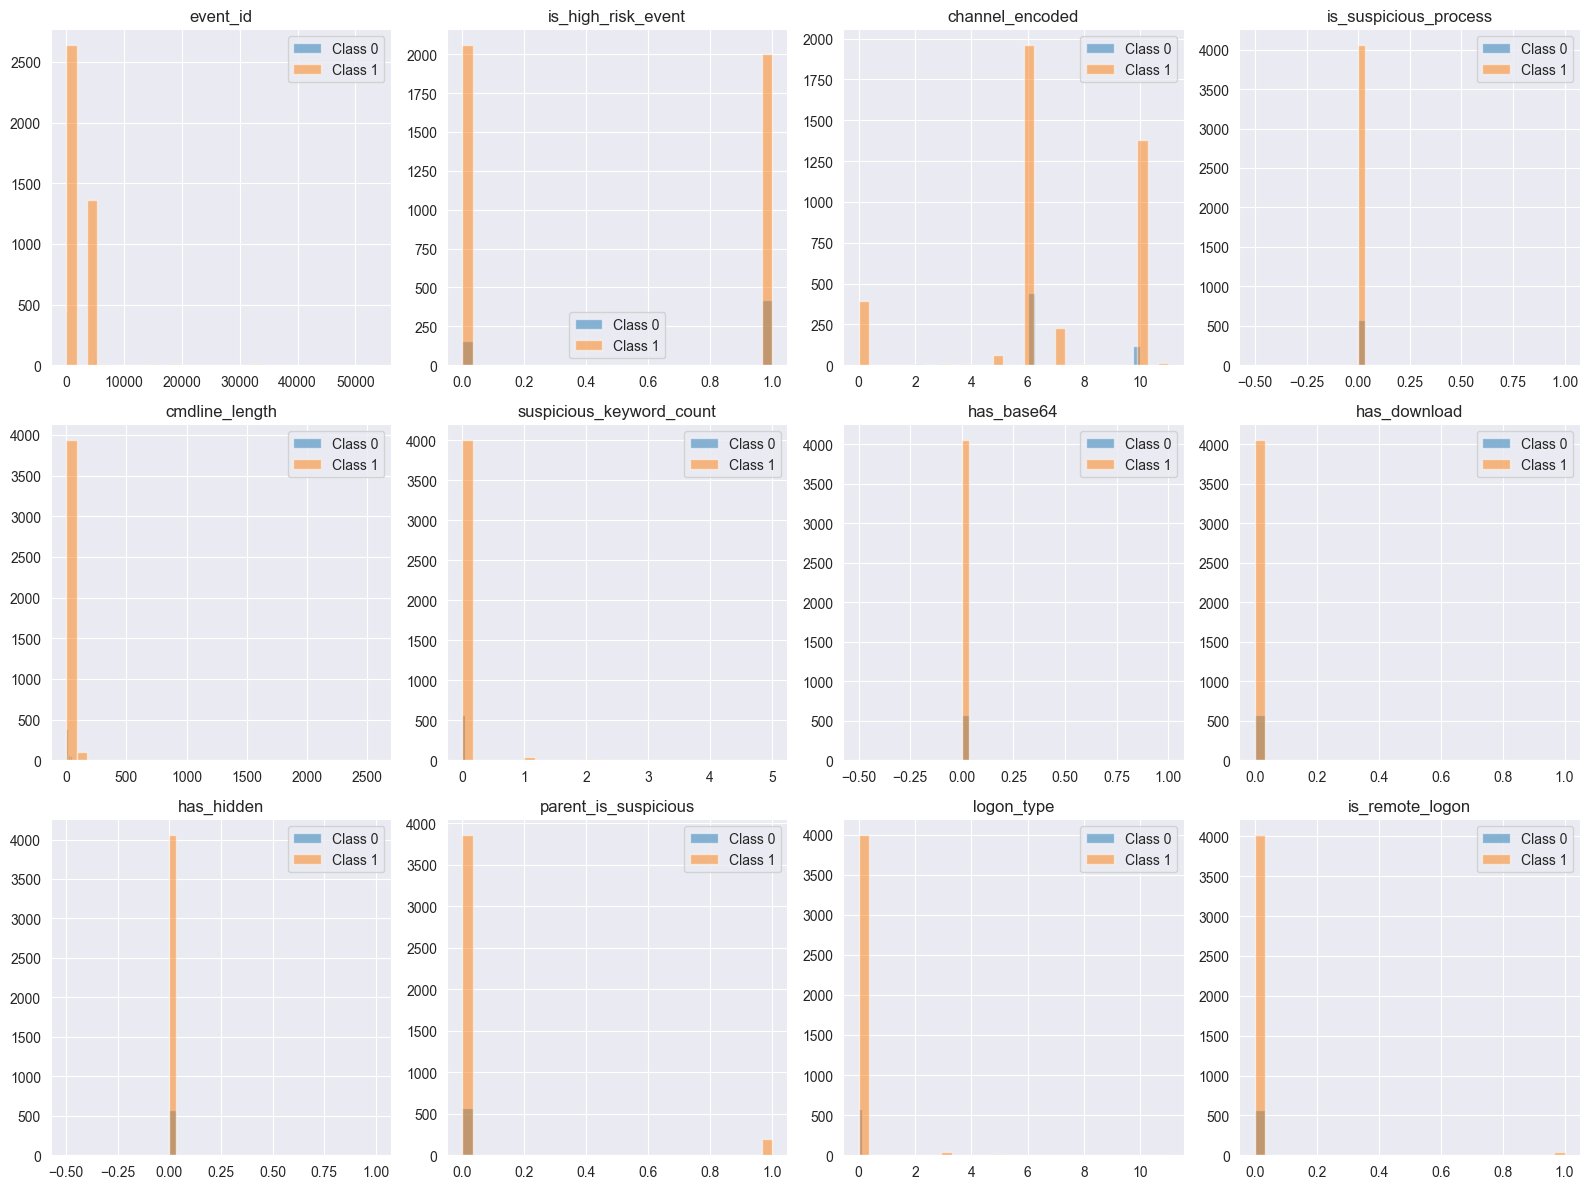

In [7]:
# Visualize feature distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(X.columns[:12]):
    ax = axes[idx]
    for label in [0, 1]:
        X[y == label][col].hist(ax=ax, alpha=0.5, label=f'Class {label}', bins=30)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Train/Test Split

In [8]:
# Remove tactic_encoded from training features (it's derived from label)
train_features = [c for c in X.columns if c != 'tactic_encoded']
X_train_data = X[train_features]

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_train_data, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {len(X_train):,} samples')
print(f'Test set: {len(X_test):,} samples')
print(f'\nClass distribution in training set:')
print(y_train.value_counts())
print(f'\nClass distribution in test set:')
print(y_test.value_counts())

Training set: 3,706 samples
Test set: 927 samples

Class distribution in training set:
is_malicious
1    3244
0     462
Name: count, dtype: int64

Class distribution in test set:
is_malicious
1    811
0    116
Name: count, dtype: int64


In [11]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Train Models

In [12]:
# Dictionary to store results
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, use_proba=True):
    """Train and evaluate a model"""
    # Train
    model.fit(X_tr, y_tr)
    
    # Predict
    y_pred = model.predict(X_te)
    
    # Probabilities
    if use_proba and hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        y_proba = y_pred
    
    # Metrics
    accuracy = (y_pred == y_te).mean()
    precision = precision_score(y_te, y_pred, zero_division=0)
    recall = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    
    try:
        roc_auc = roc_auc_score(y_te, y_proba)
    except:
        roc_auc = 0
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    
    print(f'\n{"="*60}')
    print(f'{name}')
    print(f'{"="*60}')
    print(f'Accuracy:  {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print(f'F1-Score:  {f1:.4f}')
    print(f'ROC-AUC:   {roc_auc:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_te, y_pred, target_names=['Non-malicious', 'Malicious']))
    
    return model

In [13]:
# 1. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
evaluate_model('Random Forest', rf_model, X_train_scaled, X_test_scaled, y_train, y_test)


Random Forest
Accuracy:  0.7789
Precision: 0.9779
Recall:    0.7645
F1-Score:  0.8581
ROC-AUC:   0.8980

Classification Report:
               precision    recall  f1-score   support

Non-malicious       0.35      0.88      0.50       116
    Malicious       0.98      0.76      0.86       811

     accuracy                           0.78       927
    macro avg       0.66      0.82      0.68       927
 weighted avg       0.90      0.78      0.81       927



RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_jobs=-1, random_state=42)

In [14]:
# 2. XGBoost
# Calculate scale_pos_weight for imbalanced classes
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
evaluate_model('XGBoost', xgb_model, X_train_scaled, X_test_scaled, y_train, y_test)


XGBoost
Accuracy:  0.7659
Precision: 0.9775
Recall:    0.7497
F1-Score:  0.8486
ROC-AUC:   0.8842

Classification Report:
               precision    recall  f1-score   support

Non-malicious       0.33      0.88      0.48       116
    Malicious       0.98      0.75      0.85       811

     accuracy                           0.77       927
    macro avg       0.66      0.81      0.67       927
 weighted avg       0.90      0.77      0.80       927



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [15]:
# 3. Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
evaluate_model('Gradient Boosting', gb_model, X_train_scaled, X_test_scaled, y_train, y_test)


Gradient Boosting
Accuracy:  0.8921
Precision: 0.9035
Recall:    0.9815
F1-Score:  0.9409
ROC-AUC:   0.8914

Classification Report:
               precision    recall  f1-score   support

Non-malicious       0.67      0.27      0.38       116
    Malicious       0.90      0.98      0.94       811

     accuracy                           0.89       927
    macro avg       0.79      0.62      0.66       927
 weighted avg       0.87      0.89      0.87       927



GradientBoostingClassifier(max_depth=5, random_state=42)

In [16]:
# 4. Isolation Forest (Anomaly Detection)
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.3,  # Expected proportion of anomalies
    random_state=42,
    n_jobs=-1
)

# Isolation Forest returns -1 for anomalies, 1 for normal
iso_model.fit(X_train_scaled)
iso_pred = iso_model.predict(X_test_scaled)
iso_pred_binary = (iso_pred == -1).astype(int)  # Convert: anomaly (-1) -> 1, normal (1) -> 0
iso_scores = -iso_model.score_samples(X_test_scaled)  # Negative so higher = more anomalous

accuracy = (iso_pred_binary == y_test).mean()
precision = precision_score(y_test, iso_pred_binary, zero_division=0)
recall = recall_score(y_test, iso_pred_binary, zero_division=0)
f1 = f1_score(y_test, iso_pred_binary, zero_division=0)

try:
    roc_auc = roc_auc_score(y_test, iso_scores)
except:
    roc_auc = 0

results['Isolation Forest'] = {
    'model': iso_model,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'roc_auc': roc_auc,
    'y_pred': iso_pred_binary,
    'y_proba': iso_scores
}

print(f'\n{"="*60}')
print('Isolation Forest (Anomaly Detection)')
print(f'{"="*60}')
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'ROC-AUC:   {roc_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, iso_pred_binary, target_names=['Non-malicious', 'Malicious']))


Isolation Forest (Anomaly Detection)
Accuracy:  0.3797
Precision: 0.9307
Recall:    0.3144
F1-Score:  0.4700
ROC-AUC:   0.5962

Classification Report:
               precision    recall  f1-score   support

Non-malicious       0.15      0.84      0.25       116
    Malicious       0.93      0.31      0.47       811

     accuracy                           0.38       927
    macro avg       0.54      0.58      0.36       927
 weighted avg       0.83      0.38      0.44       927



## 5. Model Comparison

In [17]:
# Comparison table
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1'] for m in results],
    'ROC-AUC': [results[m]['roc_auc'] for m in results]
}).round(4)

comparison = comparison.sort_values('F1-Score', ascending=False)
print('\nModel Comparison (sorted by F1-Score):')
comparison


Model Comparison (sorted by F1-Score):


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Gradient Boosting,0.8921,0.9035,0.9815,0.9409,0.8914
0,Random Forest,0.7789,0.9779,0.7645,0.8581,0.8980
1,XGBoost,0.7659,0.9775,0.7497,0.8486,0.8842
3,Isolation Forest,0.3797,0.9307,0.3144,0.4700,0.5962


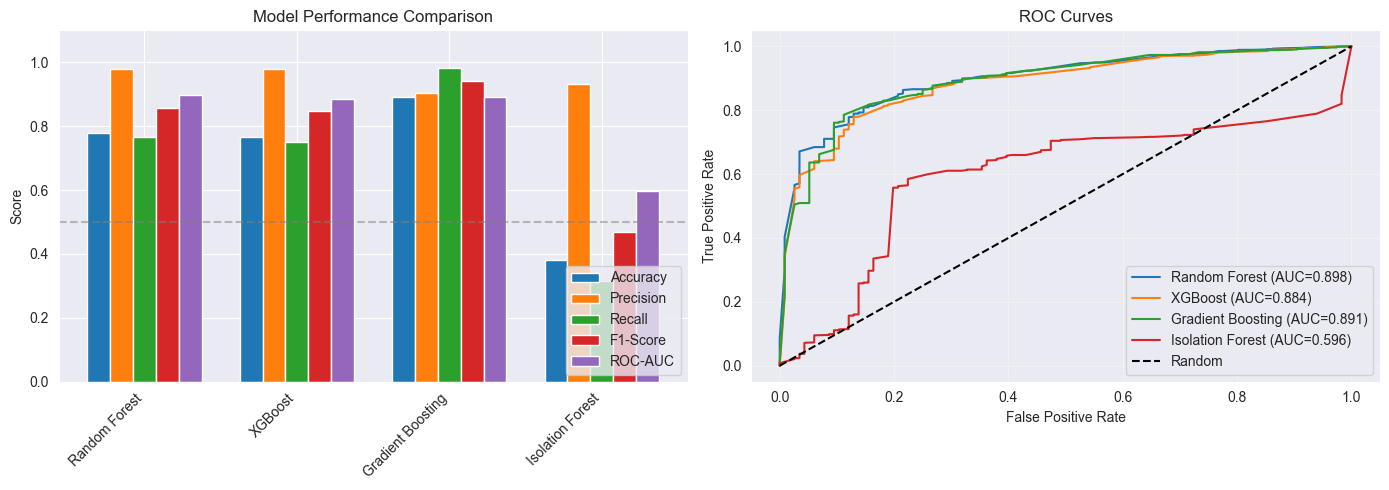

In [23]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metric_keys = {'Accuracy': 'accuracy', 'Precision': 'precision', 'Recall': 'recall', 'F1-Score': 'f1', 'ROC-AUC': 'roc_auc'}
x = np.arange(len(results))
width = 0.15

ax = axes[0]
for i, metric in enumerate(metrics):
    values = [results[m][metric_keys[metric]] for m in results]
    ax.bar(x + i*width, values, width, label=metric)

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results.keys(), rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# ROC curves
ax = axes[1]
for name, res in results.items():
    if res['roc_auc'] > 0:
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        ax.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

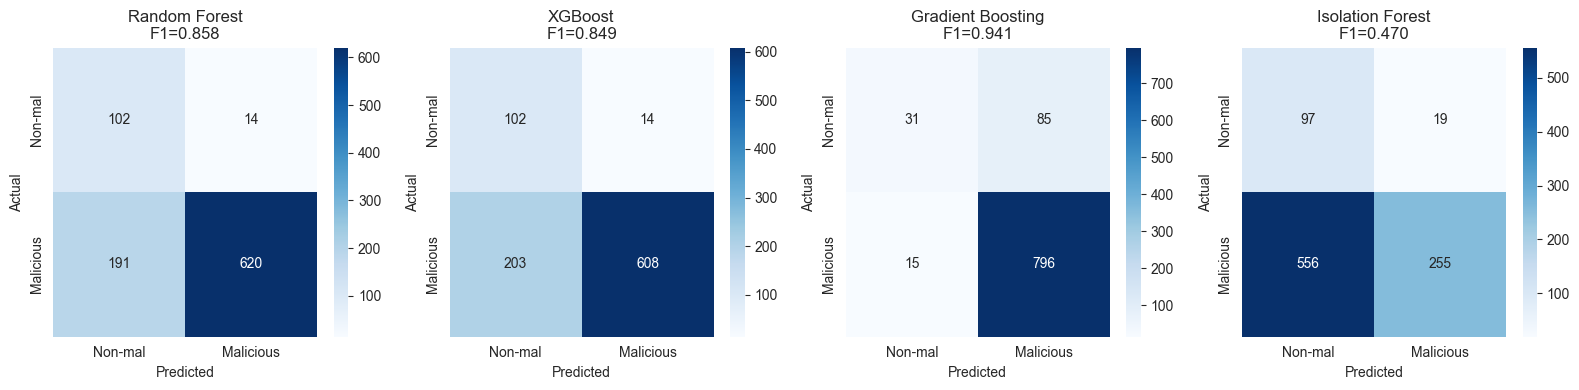

In [24]:
# Confusion matrices
fig, axes = plt.subplots(1, len(results), figsize=(4*len(results), 4))

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx] if len(results) > 1 else axes
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-mal', 'Malicious'],
                yticklabels=['Non-mal', 'Malicious'])
    ax.set_title(f'{name}\nF1={res["f1"]:.3f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 6. Feature Importance Analysis

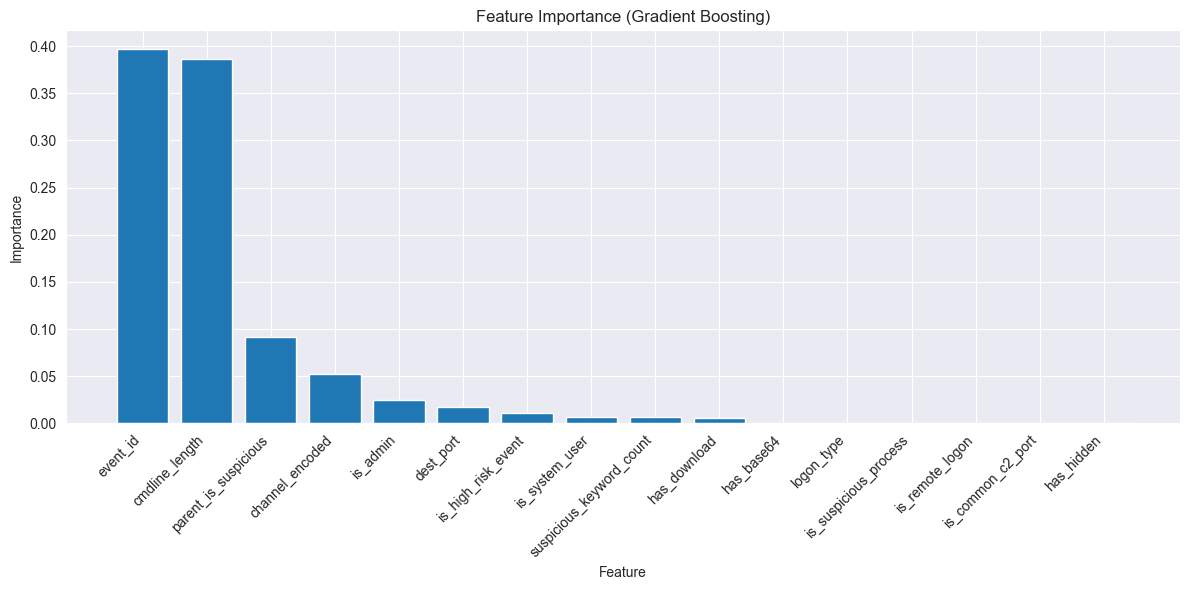


Top 10 most important features:
  1. event_id: 0.3968
  2. cmdline_length: 0.3859
  3. parent_is_suspicious: 0.0919
  4. channel_encoded: 0.0519
  5. is_admin: 0.0247
  6. dest_port: 0.0170
  7. is_high_risk_event: 0.0111
  8. is_system_user: 0.0069
  9. suspicious_keyword_count: 0.0067
  10. has_download: 0.0055


In [25]:
# Feature importance from best model (XGBoost or Random Forest)
best_model_name = comparison.iloc[0]['Model']
best_model = results[best_model_name]['model']

if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
    feature_names = train_features
    
    # Sort by importance
    indices = np.argsort(importance)[::-1]
    
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(importance)), importance[indices])
    plt.xticks(range(len(importance)), [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.xlabel('Feature')
    plt.ylabel('Importance')
    plt.title(f'Feature Importance ({best_model_name})')
    plt.tight_layout()
    plt.show()
    
    print(f'\nTop 10 most important features:')
    for i in range(min(10, len(importance))):
        print(f'  {i+1}. {feature_names[indices[i]]}: {importance[indices[i]]:.4f}')

## 7. Cross-Validation

In [26]:
# 5-fold cross-validation for best model
print(f'Cross-validation for {best_model_name}:')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Re-create model (XGBoost or RF)
if 'XGBoost' in best_model_name:
    cv_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos, random_state=42,
        use_label_encoder=False, eval_metric='logloss'
    )
else:
    cv_model = RandomForestClassifier(
        n_estimators=100, max_depth=10, class_weight='balanced',
        random_state=42, n_jobs=-1
    )

# Cross-validation scores
cv_scores = cross_val_score(cv_model, X_train_scaled, y_train, cv=cv, scoring='f1')
cv_accuracy = cross_val_score(cv_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
cv_precision = cross_val_score(cv_model, X_train_scaled, y_train, cv=cv, scoring='precision')
cv_recall = cross_val_score(cv_model, X_train_scaled, y_train, cv=cv, scoring='recall')

print(f'\n5-Fold Cross-Validation Results:')
print(f'  Accuracy:  {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std()*2:.4f})')
print(f'  Precision: {cv_precision.mean():.4f} (+/- {cv_precision.std()*2:.4f})')
print(f'  Recall:    {cv_recall.mean():.4f} (+/- {cv_recall.std()*2:.4f})')
print(f'  F1-Score:  {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')

Cross-validation for Gradient Boosting:

5-Fold Cross-Validation Results:
  Accuracy:  0.7769 (+/- 0.0328)
  Precision: 0.9829 (+/- 0.0147)
  Recall:    0.7583 (+/- 0.0353)
  F1-Score:  0.8560 (+/- 0.0237)


## 8. Save Best Model

In [27]:
import os

# Create models directory
os.makedirs('models', exist_ok=True)

# Save best model
best_model_trained = results[best_model_name]['model']
model_path = f'models/threat_detector_{best_model_name.lower().replace(" ", "_")}.pkl'

with open(model_path, 'wb') as f:
    pickle.dump({
        'model': best_model_trained,
        'scaler': scaler,
        'feature_engineer': fe,
        'feature_names': train_features,
        'metrics': {
            'accuracy': results[best_model_name]['accuracy'],
            'precision': results[best_model_name]['precision'],
            'recall': results[best_model_name]['recall'],
            'f1': results[best_model_name]['f1'],
            'roc_auc': results[best_model_name]['roc_auc']
        }
    }, f)

print(f'Best model saved to: {model_path}')
print(f'\nModel: {best_model_name}')
print(f'F1-Score: {results[best_model_name]["f1"]:.4f}')
print(f'ROC-AUC: {results[best_model_name]["roc_auc"]:.4f}')

Best model saved to: models/threat_detector_gradient_boosting.pkl

Model: Gradient Boosting
F1-Score: 0.9409
ROC-AUC: 0.8914


In [28]:
# Save all models
for name, res in results.items():
    model_file = f'models/{name.lower().replace(" ", "_")}_model.pkl'
    with open(model_file, 'wb') as f:
        pickle.dump({
            'model': res['model'],
            'scaler': scaler,
            'metrics': {
                'accuracy': res['accuracy'],
                'precision': res['precision'],
                'recall': res['recall'],
                'f1': res['f1'],
                'roc_auc': res['roc_auc']
            }
        }, f)
    print(f'Saved: {model_file}')

print(f'\nAll models saved to models/ directory')

Saved: models/random_forest_model.pkl
Saved: models/xgboost_model.pkl
Saved: models/gradient_boosting_model.pkl
Saved: models/isolation_forest_model.pkl

All models saved to models/ directory


## 9. Summary

In [29]:
print('='*70)
print('TRAINING SUMMARY')
print('='*70)
print(f'\nDataset: EVTX-ATTACK-SAMPLES')
print(f'Total events: {len(df):,}')
print(f'Training samples: {len(X_train):,}')
print(f'Test samples: {len(X_test):,}')
print(f'Features: {len(train_features)}')
print(f'\nBest Model: {best_model_name}')
print(f'  - F1-Score: {results[best_model_name]["f1"]:.4f}')
print(f'  - Precision: {results[best_model_name]["precision"]:.4f}')
print(f'  - Recall: {results[best_model_name]["recall"]:.4f}')
print(f'  - ROC-AUC: {results[best_model_name]["roc_auc"]:.4f}')
print(f'\nModels saved to: models/')
print('='*70)

TRAINING SUMMARY

Dataset: EVTX-ATTACK-SAMPLES
Total events: 4,633
Training samples: 3,706
Test samples: 927
Features: 16

Best Model: Gradient Boosting
  - F1-Score: 0.9409
  - Precision: 0.9035
  - Recall: 0.9815
  - ROC-AUC: 0.8914

Models saved to: models/
